In [63]:
# -*- coding: utf-8 -*-
"""


Actualizado: 16 de septiembre de 2025
"""
# ---------- Librerias -------------
import csv
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import statistics as stats
import math
import re
from datetime import datetime

# ---------- Funciones -------------
def Clasification_Results(Ruta_Archivo: str) -> dict:
    Nombre_Dispositivo = Ruta_Archivo.split("Results_")[-1].split("_")[0]
    Model={Nombre_Dispositivo: {}}

    with open(Ruta_Archivo, mode="r", newline='', encoding='utf-8') as infile:
        reader = csv.DictReader(infile)
        header = reader.fieldnames

        for header_index in range(len(header)):
            model_name = header[header_index].split(' - ')[0]
            Data_type = header[header_index].split(' - ')[-1]
            
            if(Data_type == 'prediction'):
                Model[Nombre_Dispositivo][model_name] = { 
                    'Embarcacion': 0,
                    'Falso_Negativo':0,
                    'Falso_Positivo':0,
                    'No_Embarcacion':0,
                    'Probs':[],
                    'Speed':[]
                    }
        for row in reader:
            for field, column in row.items():
                model_name = field.split(' - ')[0]
                Data_type = field.split(' - ')[-1]
                
                if(Data_type == 'prediction'):
                    if(row['Main_Label']==column):
                        if(column=='1'):
                            Model[Nombre_Dispositivo][model_name]['Embarcacion']+=1
                        else:
                            Model[Nombre_Dispositivo][model_name]['No_Embarcacion']+=1
                    else:
                        if(column=='1'):
                            Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1
                        else:
                            Model[Nombre_Dispositivo][model_name]['Falso_Negativo']+=1
                
                elif(Data_type == 'conf'):
                    Model[Nombre_Dispositivo][model_name]['Probs'].append(float(column))

                elif(Data_type == 'time [ms]'):
                    Model[Nombre_Dispositivo][model_name]['Speed'].append(float(column))

    return Model

def modelo_sort_key(modelo: str, type_order, size_order):
    _, size, tipo = modelo.split("_")
    return (type_order.index(tipo), size_order.index(int(size)))

def extract_number(value):
    match = re.search(r"[-+]?\d*\.?\d+", value)
    return float(match.group()) if match else None


Matriz de confusion media - (promediado con los experimentos en diversos dispositivos)
Para el modelo Modelo_1056_ExtraLarge:
Embarcaciones: 11.433151651170247±0.0%
Sin embarcaciones: 87.476755370311±0.0%
Falso Negativo: 0.6027572940044886±0.0%
Falso Positivo: 0.4873356845142674±0.0%

Para el modelo Modelo_832_ExtraLarge:
Embarcaciones: 11.394677781340173±0.0%
Sin embarcaciones: 87.62423853799295±0.0%
Falso Negativo: 0.6412311638345624±0.0%
Falso Positivo: 0.33985251683231804±0.0%

Para el modelo Modelo_640_ExtraLarge:
Embarcaciones: 11.760179544725874±0.0%
Sin embarcaciones: 87.68194934273805±0.0%
Falso Negativo: 0.2757294004488618±0.0%
Falso Positivo: 0.28214171208720745±0.0%

Para el modelo Modelo_416_ExtraLarge:
Embarcaciones: 11.856364219301058±0.0%
Sin embarcaciones: 87.84866944533505±0.0%
Falso Negativo: 0.17954472587367745±0.0%
Falso Positivo: 0.11542160949022122±0.0%

Para el modelo Modelo_1056_Large:
Embarcaciones: 11.51651170246874±0.0%
Sin embarcaciones: 87.62423853799295±0

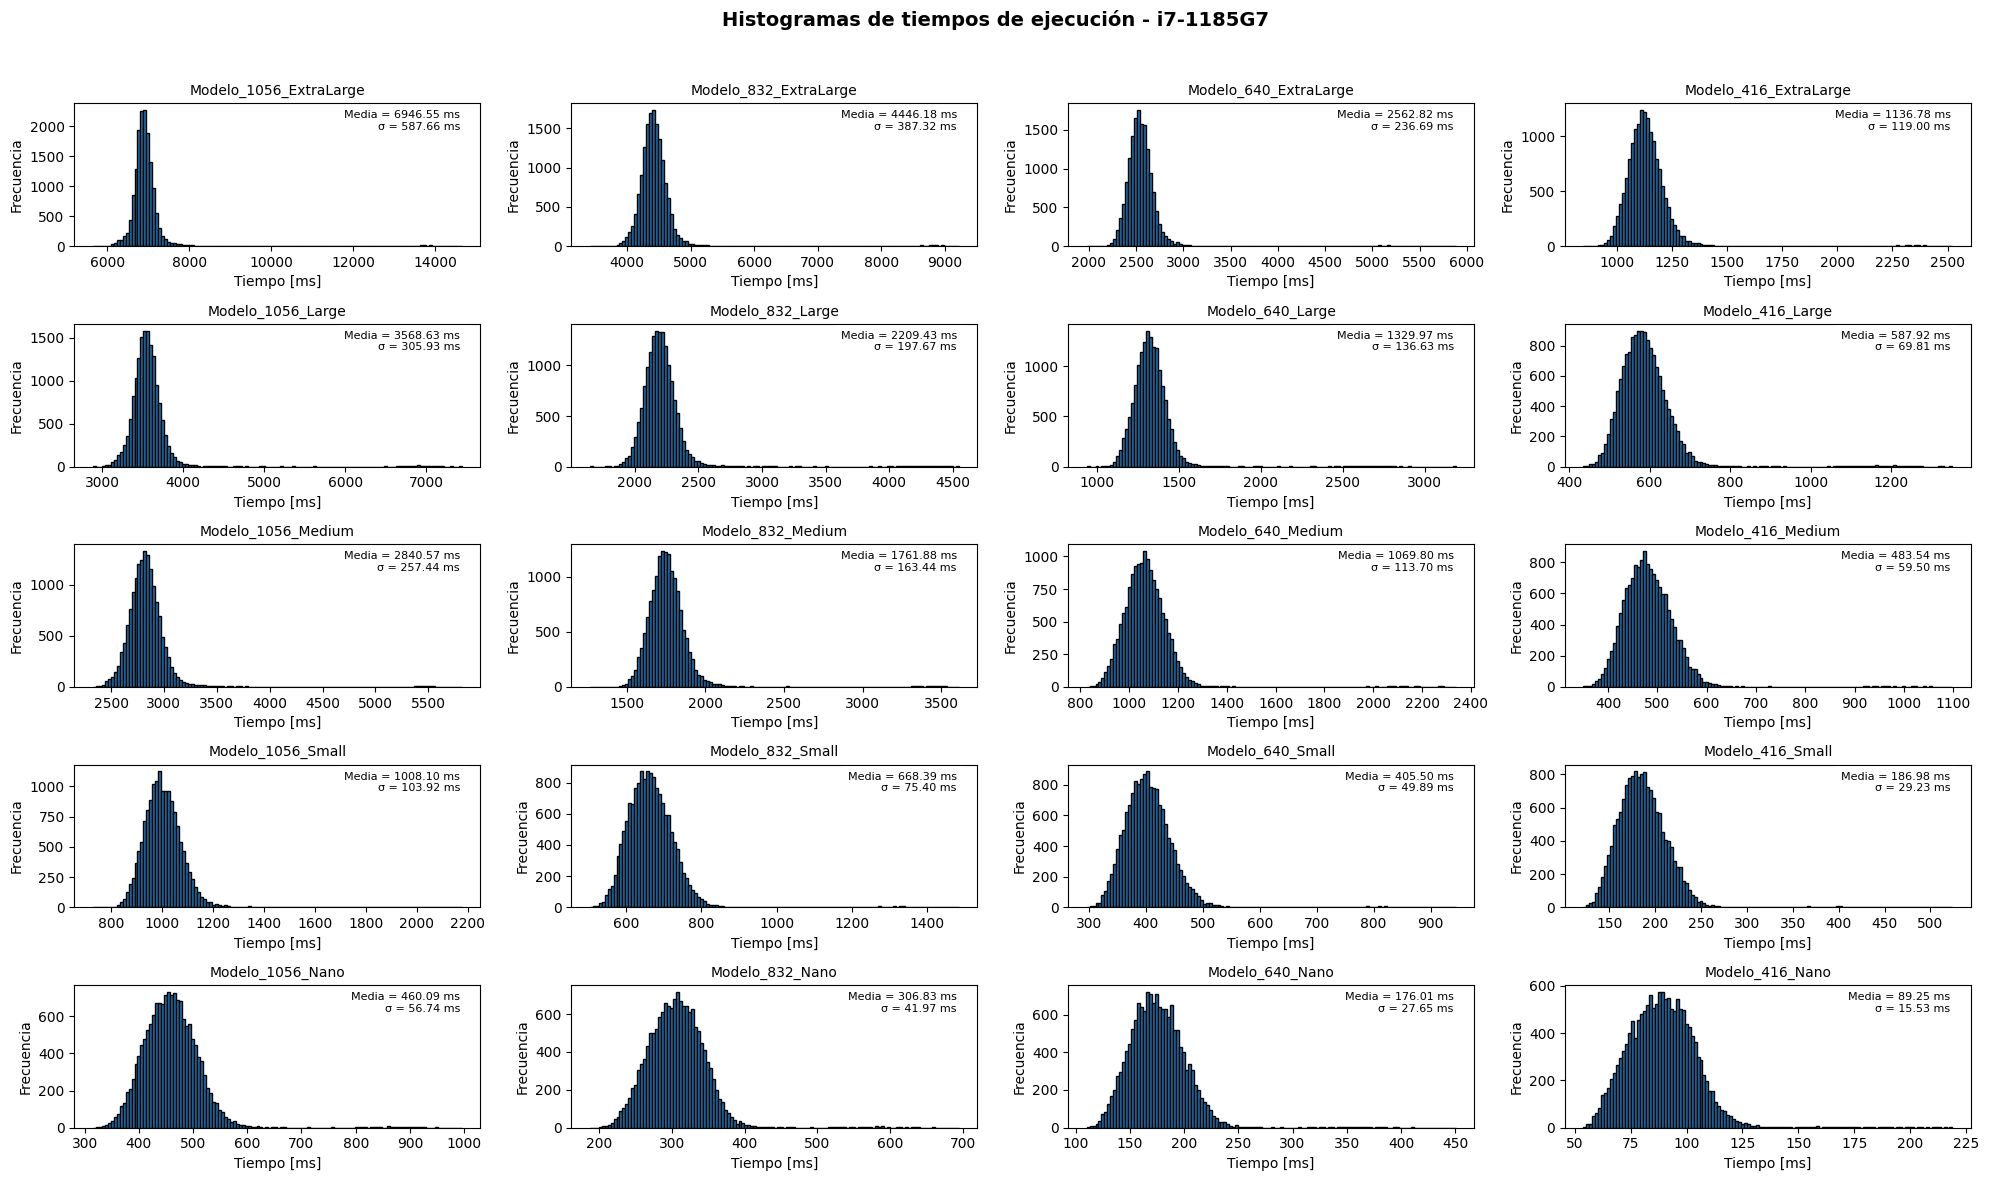

Para el dispositivo i9-11900k, se tienen los siguientes tiempos de ejecucion: 


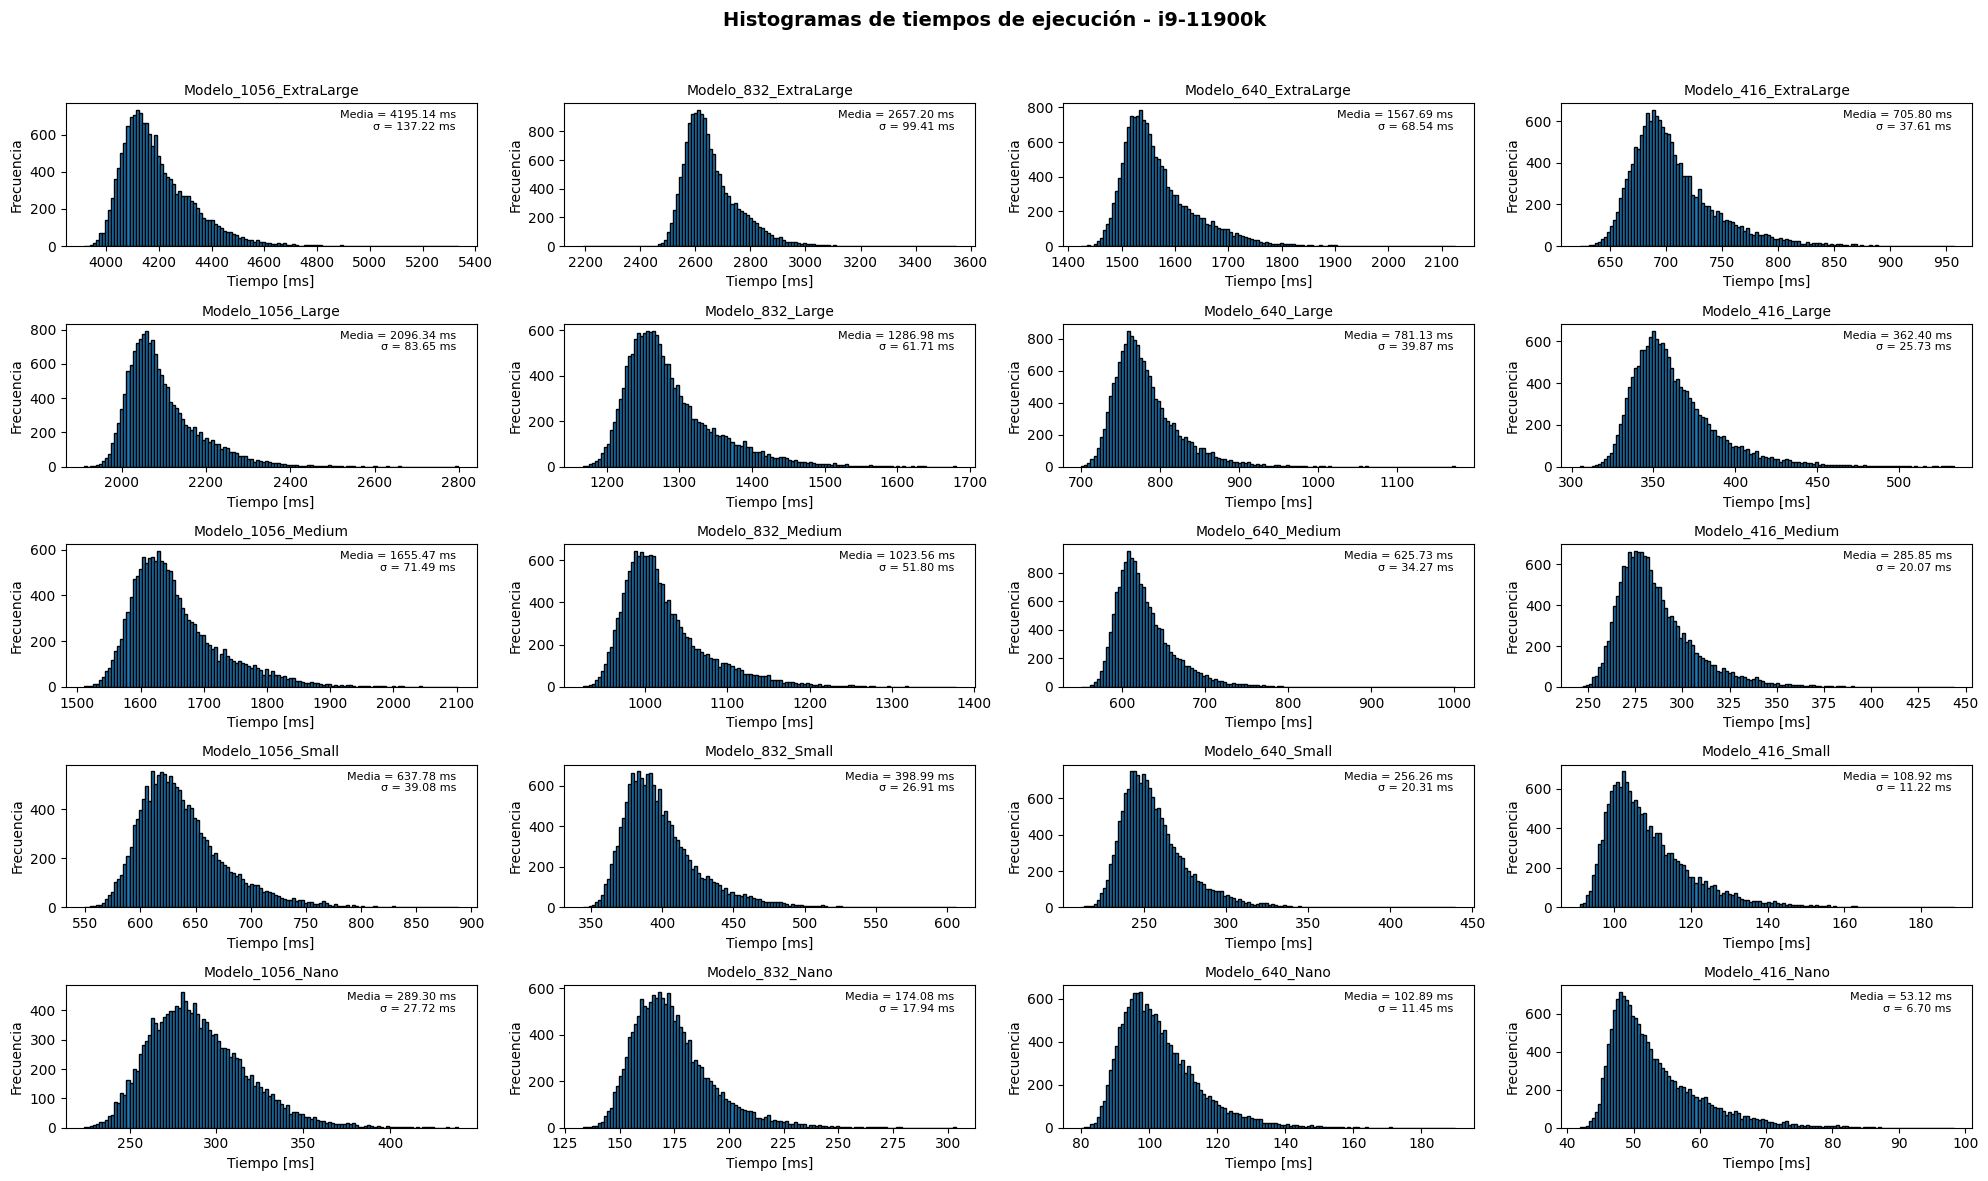

Para el dispositivo RTX4090, se tienen los siguientes tiempos de ejecucion: 


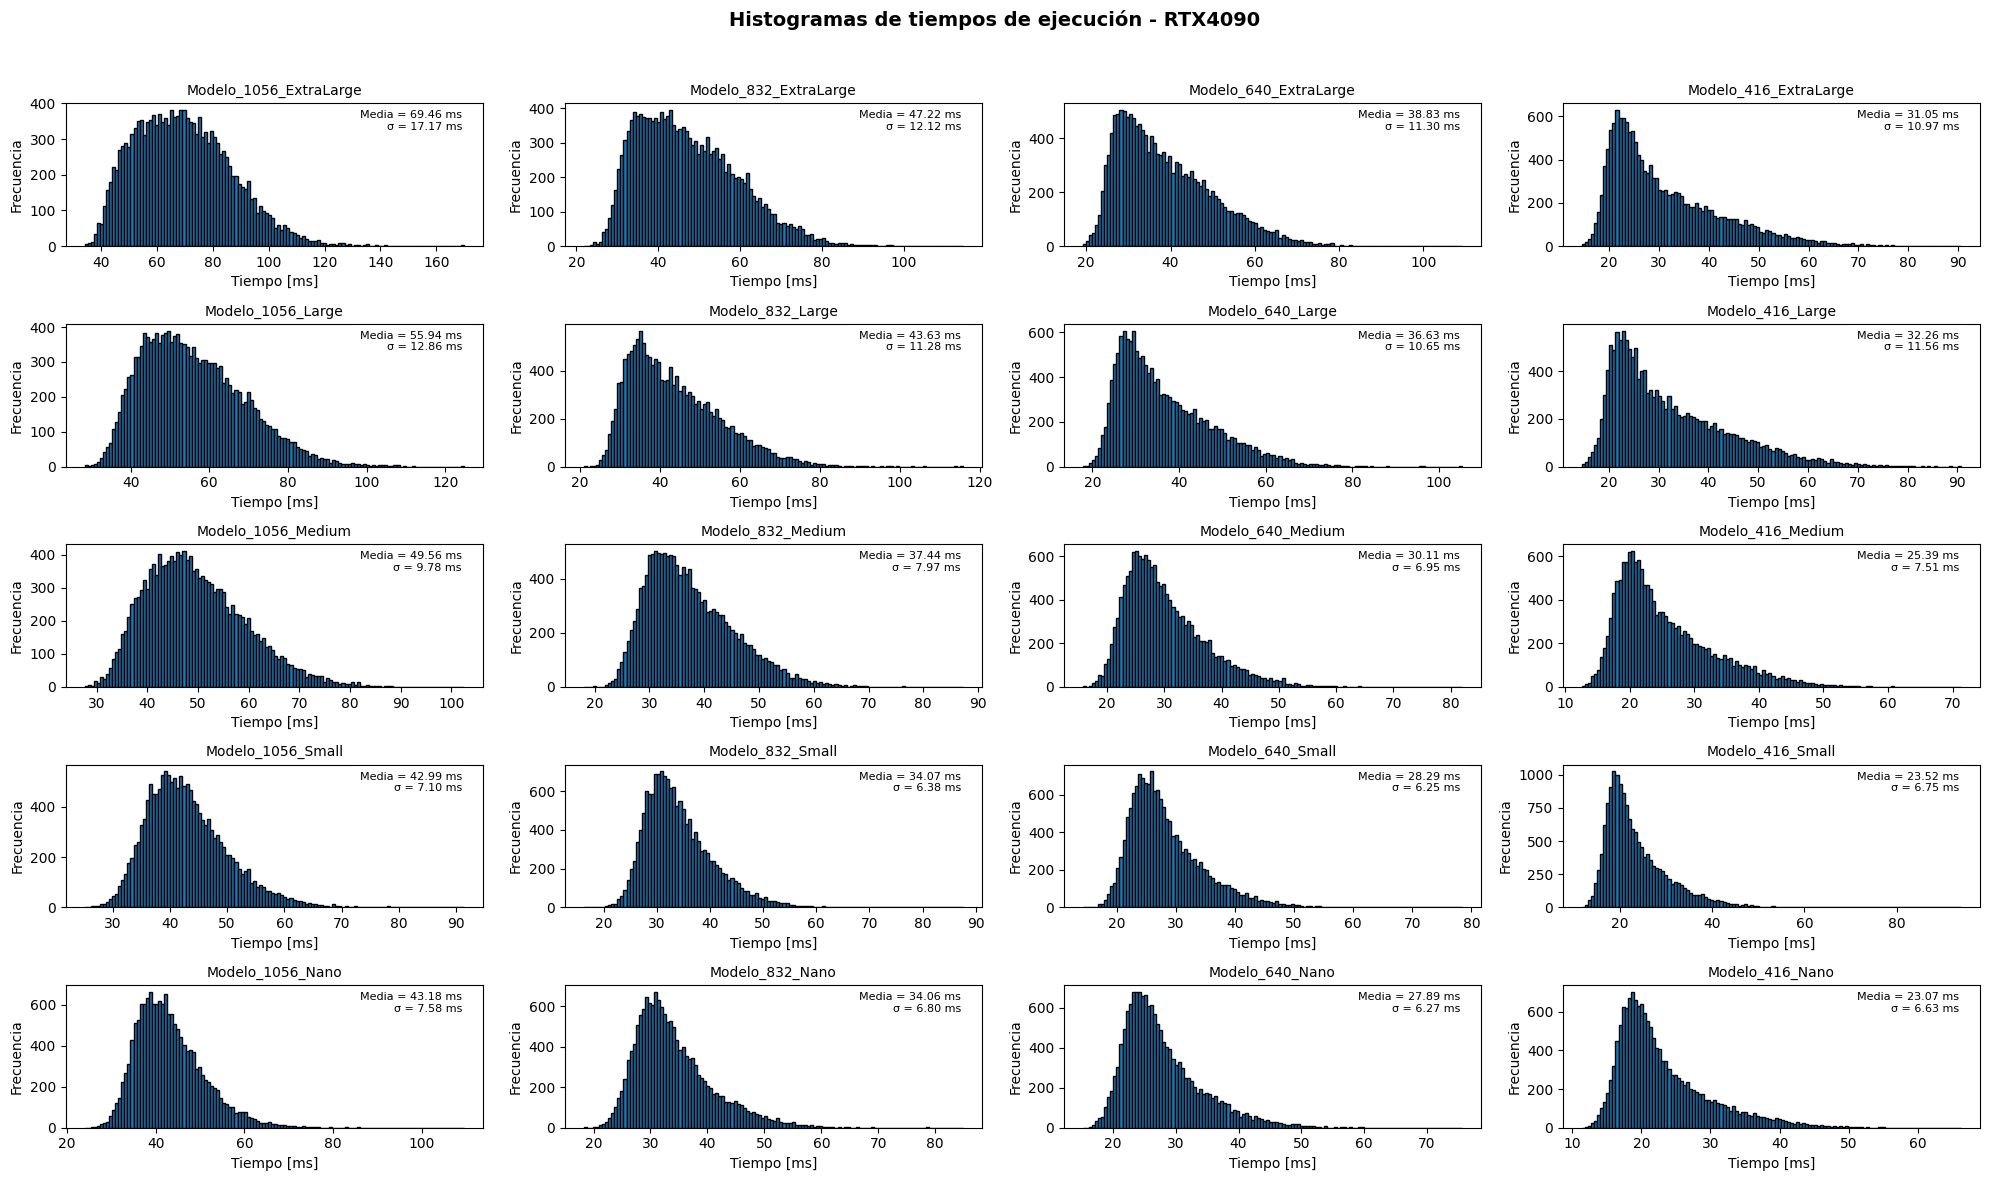

Para el dispositivo RTXA4000, se tienen los siguientes tiempos de ejecucion: 


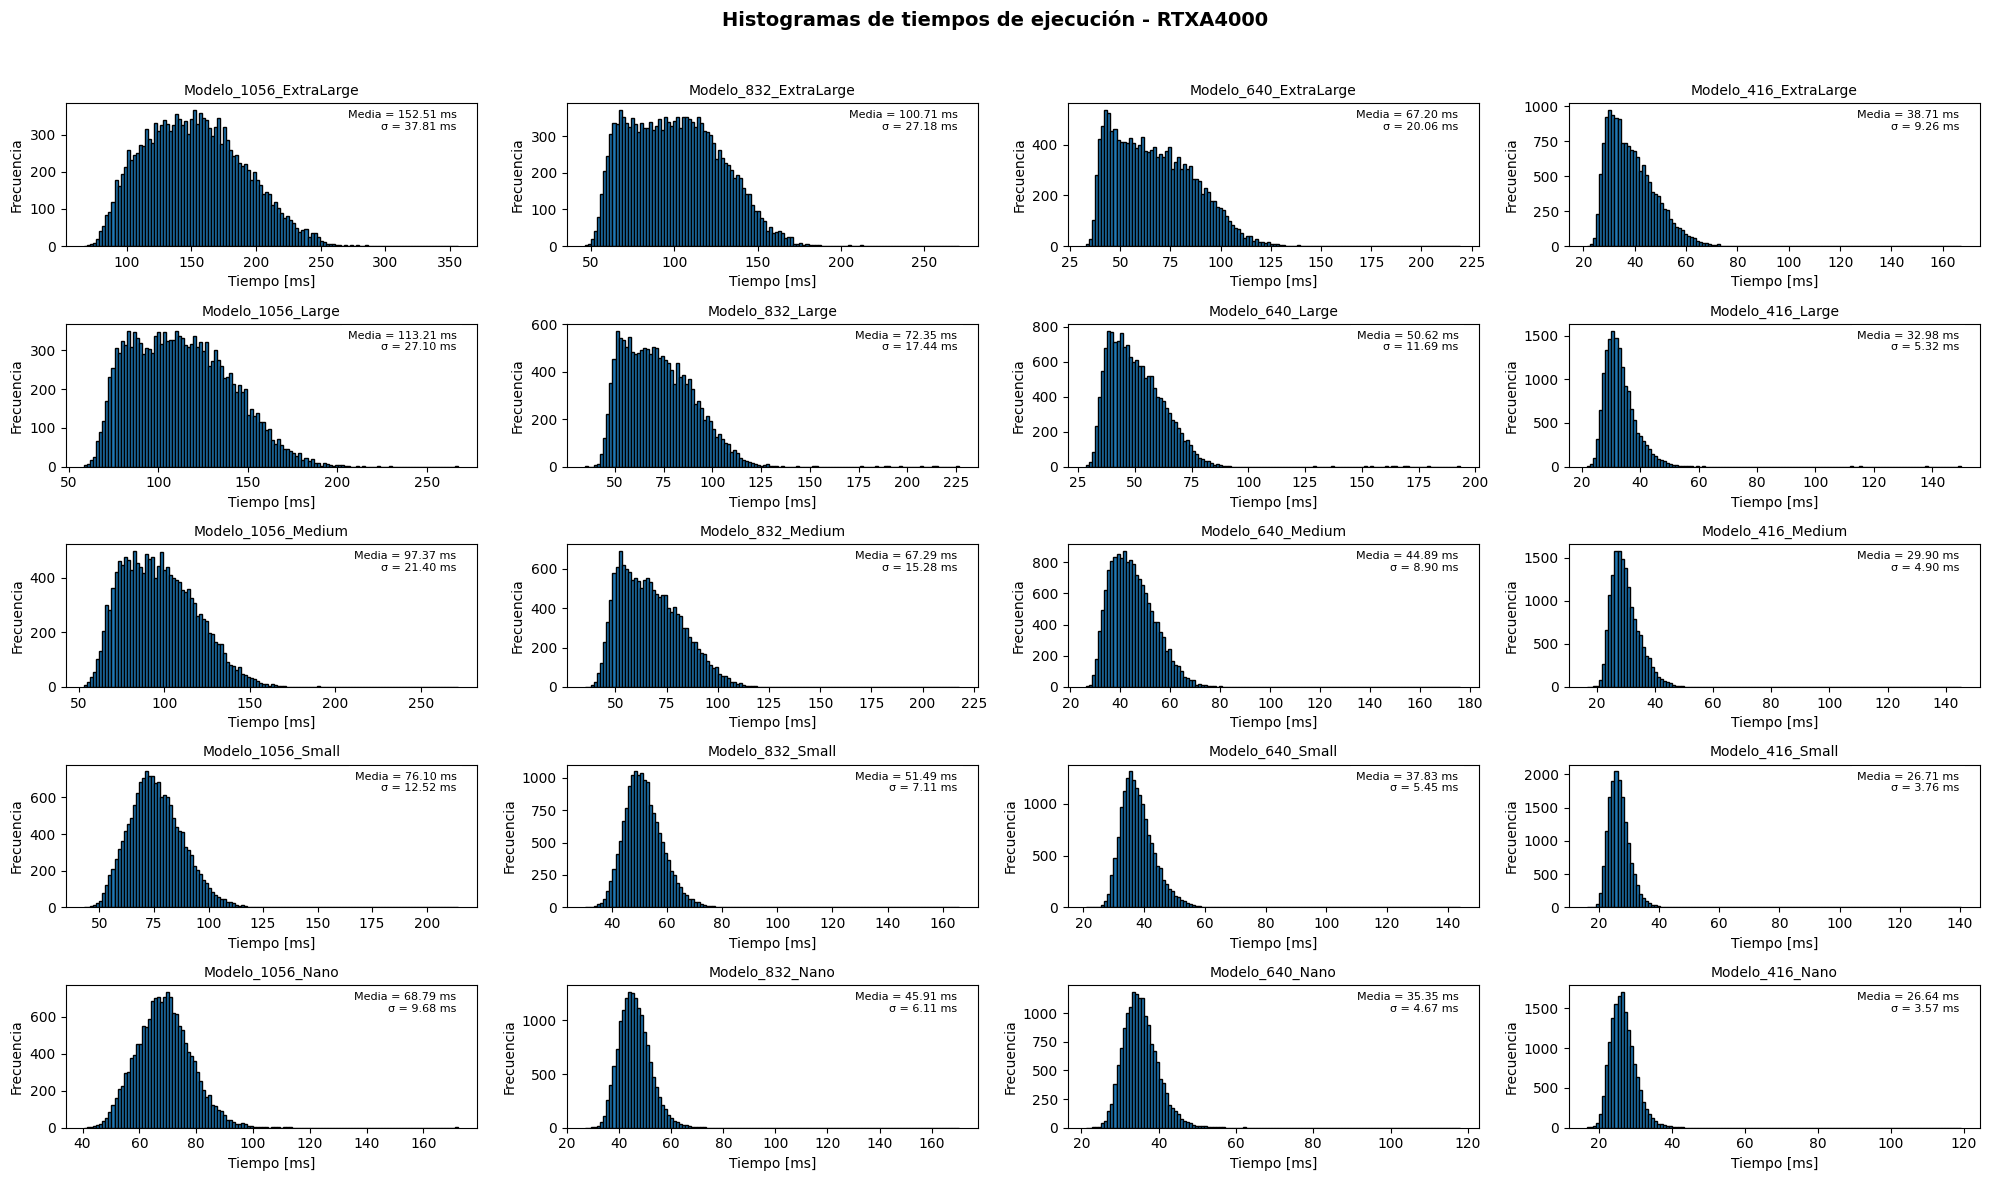

Para el dispositivo Ryzen7-9800X3D, se tienen los siguientes tiempos de ejecucion: 


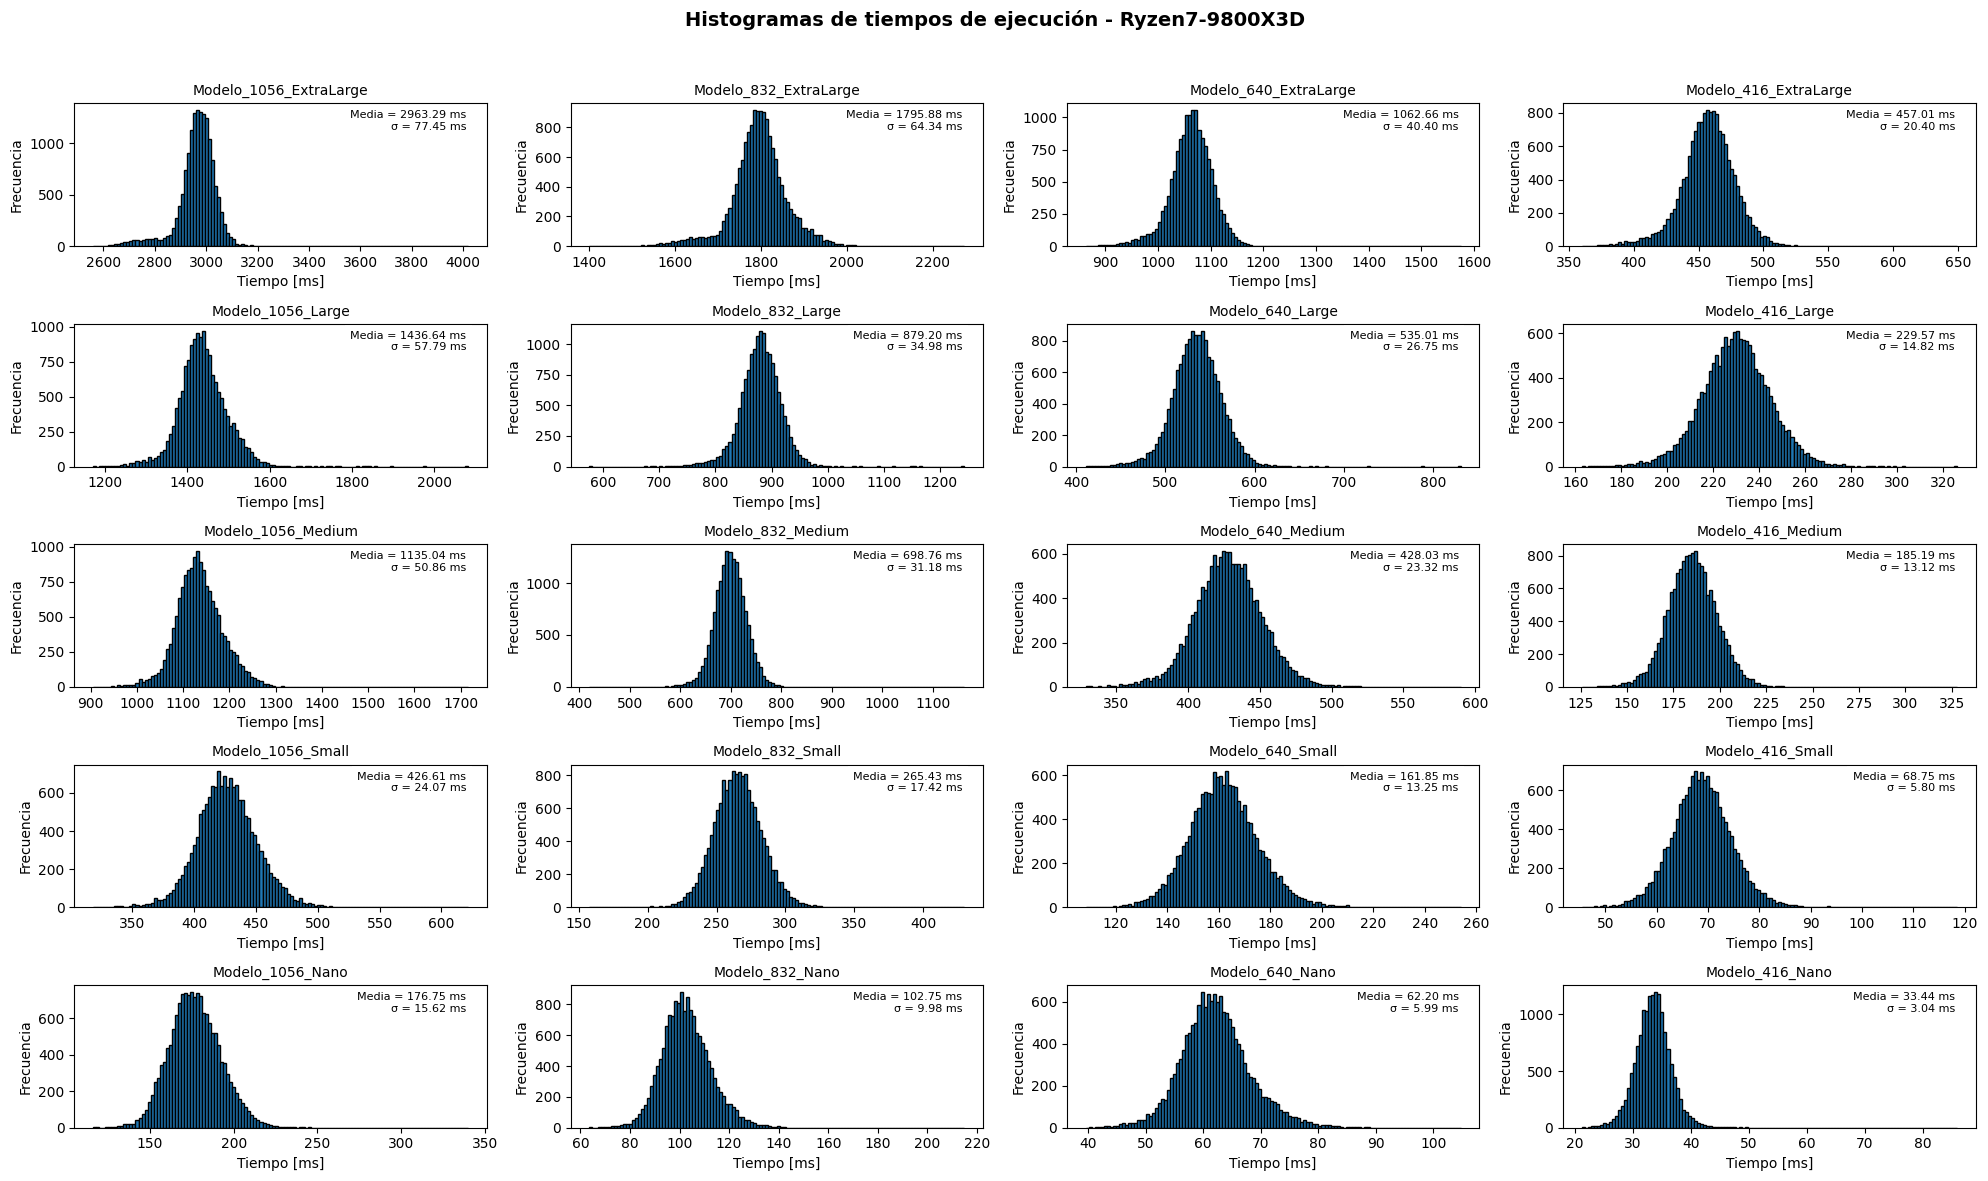

In [29]:
# ---------- Ejecucion -------------
Ruta_Archivos = os.path.normpath(os.path.join("..","..","..","Resultados_Clasificacion"))
Ruta_Archivos = [os.path.normpath(os.path.join(Ruta_Archivos,file))for file in os.listdir(Ruta_Archivos)]

Ruta_Salida = os.path.normpath(os.path.join("..","..",".."))


type_order = ["ExtraLarge", "Large", "Medium", "Small", "Nano"]
size_order = [1056, 832, 640, 416]

Dispositivos = {}
Resultados_Modelos = {}
Dispositivos_ordenados = {}

for file in Ruta_Archivos:
    Dispositivos.update(Clasification_Results(file))

for dispositivo, modelos in Dispositivos.items():
    modelos_ordenados = dict(
        sorted(modelos.items(), key=lambda x: modelo_sort_key(x[0], type_order, size_order))
    )
    Dispositivos_ordenados[dispositivo] = modelos_ordenados


for modelo, Resultados in next(iter(Dispositivos_ordenados.values())).items():
    Resultados_Modelos[modelo] = {
        'Embarcacion': [],
        'Falso_Negativo':[],
        'Falso_Positivo':[],
        'No_Embarcacion':[],
        'Probs':[],
    }
    Total_Registros = Resultados['Embarcacion']+Resultados['Falso_Negativo']+Resultados['Falso_Positivo']+Resultados['No_Embarcacion']


for _, Modelos in Dispositivos_ordenados.items():
    for modelo, resultados in Modelos.items():
        for resultado, Valor in resultados.items():
            if(resultado == 'Probs'):
                for prob in Valor:
                    Resultados_Modelos[modelo][resultado].append(prob)
            elif(resultado != 'Speed'):
                Resultados_Modelos[modelo][resultado].append(Valor)
            
print("Matriz de confusion media - (promediado con los experimentos en diversos dispositivos)")
for modelo, resultados in Resultados_Modelos.items():
    print(f"Para el modelo {modelo}:")
    print(f"Embarcaciones: {stats.mean(resultados['Embarcacion'])*100/Total_Registros}±{stats.stdev(resultados['Embarcacion'])*100/Total_Registros}%")
    print(f"Sin embarcaciones: {stats.mean(resultados['No_Embarcacion'])*100/Total_Registros}±{stats.stdev(resultados['No_Embarcacion'])*100/Total_Registros}%")
    print(f"Falso Negativo: {stats.mean(resultados['Falso_Negativo'])*100/Total_Registros}±{stats.stdev(resultados['Falso_Negativo'])*100/Total_Registros}%")
    print(f"Falso Positivo: {stats.mean(resultados['Falso_Positivo'])*100/Total_Registros}±{stats.stdev(resultados['Falso_Positivo'])*100/Total_Registros}%\n")

for dispositivo, modelos in Dispositivos.items():
    print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion: ")
    for modelo, resultados in modelos.items():
        print(f"{modelo}: {stats.mean(resultados['Speed']):.2f}±{stats.stdev(resultados['Speed']):.2f} [ms]")
    print("\n")

with PdfPages(os.path.normpath(os.path.join(Ruta_Salida,"histogramas_por_dispositivo.pdf"))) as pdf:
    for dispositivo, modelos in Dispositivos_ordenados.items():
        print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion: ")
        
        fig, axs = plt.subplots(5, 4, figsize=(20, 12))
        axs = axs.flatten()
        
        for i, (modelo, resultados) in enumerate(modelos.items()):
            if i >= 20:  
                break

            datos = resultados['Speed']
            media = stats.mean(datos)
            sigma = stats.stdev(datos)

            axs[i].hist(datos, bins=int(math.sqrt(len(datos))), edgecolor="black")
            axs[i].set_title(modelo, fontsize=10)

            axs[i].text(
                0.95, 0.95,
                f"Media = {media:.2f} ms\nσ = {sigma:.2f} ms",
                ha="right", va="top",
                transform=axs[i].transAxes,
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")  
            )

            axs[i].set_xlabel("Tiempo [ms]")
            axs[i].set_ylabel("Frecuencia")

        for j in range(i + 1, len(axs)):
            axs[j].axis("off")

        plt.suptitle(f"Histogramas de tiempos de ejecución - {dispositivo}", 
                        fontsize=14, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.96])

        plt.show()


        pdf.savefig(fig)
        plt.close(fig)  




La base de datos contiene un aproximado de 10966 correos diferentes
La cantidad de correos sin imagenes son: 5076, corresponde a un 46.289% de los correos

La cantidad de correos con imagenes son: 5890, corresponde a un 53.711% de los correos
Los correos que tienen imagenes pero no contienen embarcaciones son: 5280, corresponde a un 48.149% de los correos
Los correos que tienen imagenes y que contienen embarcaciones son: 610, corresponde a un 5.563% de los correos

En total se disponen de 13718 Imagenes sin embarcaciones
En total se disponen de 1877 Imagenes con embarcaciones
Se obtuvieron un total de 15595 Imagenes


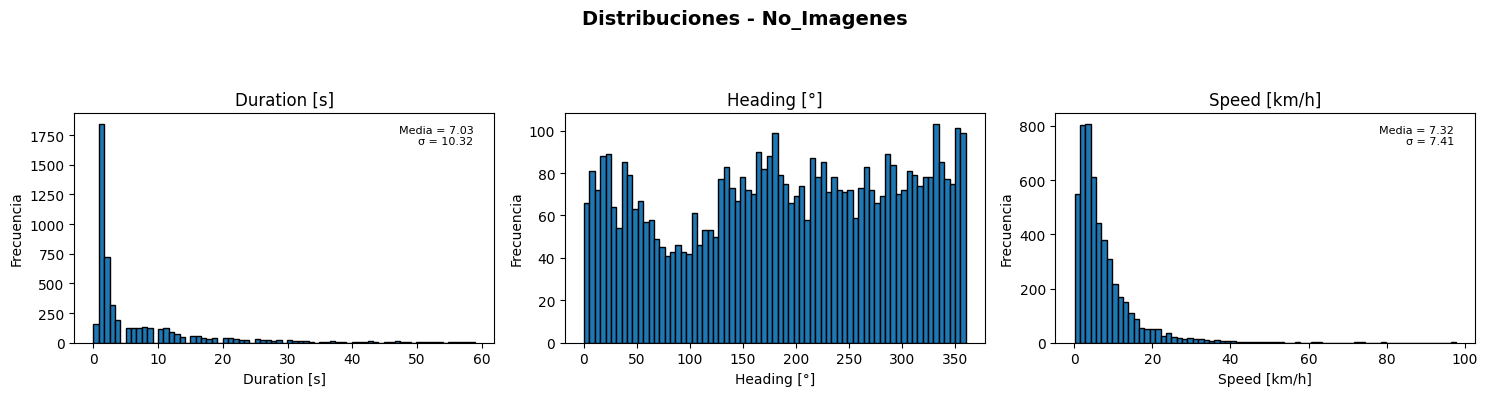

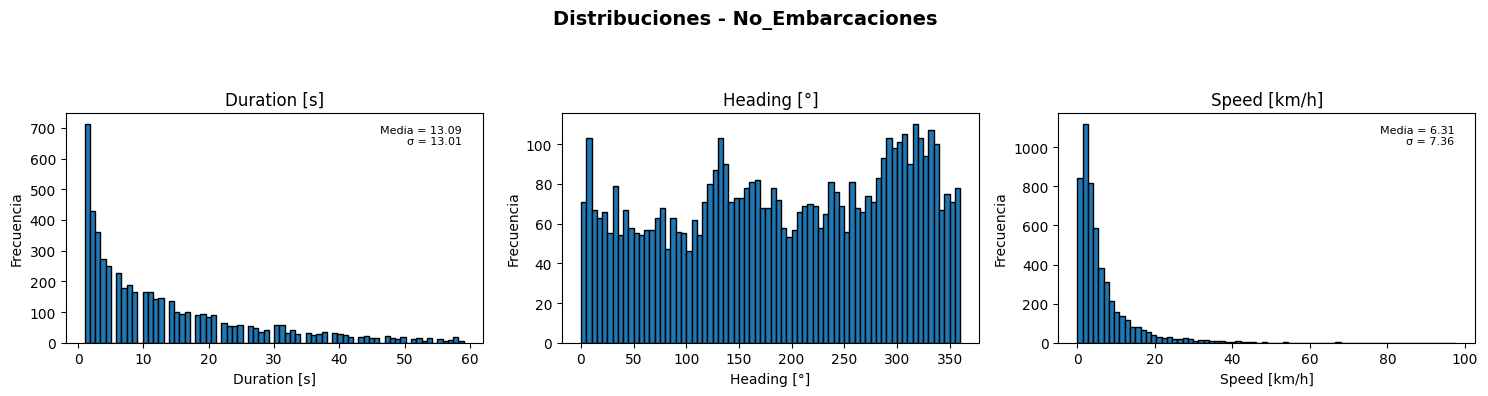

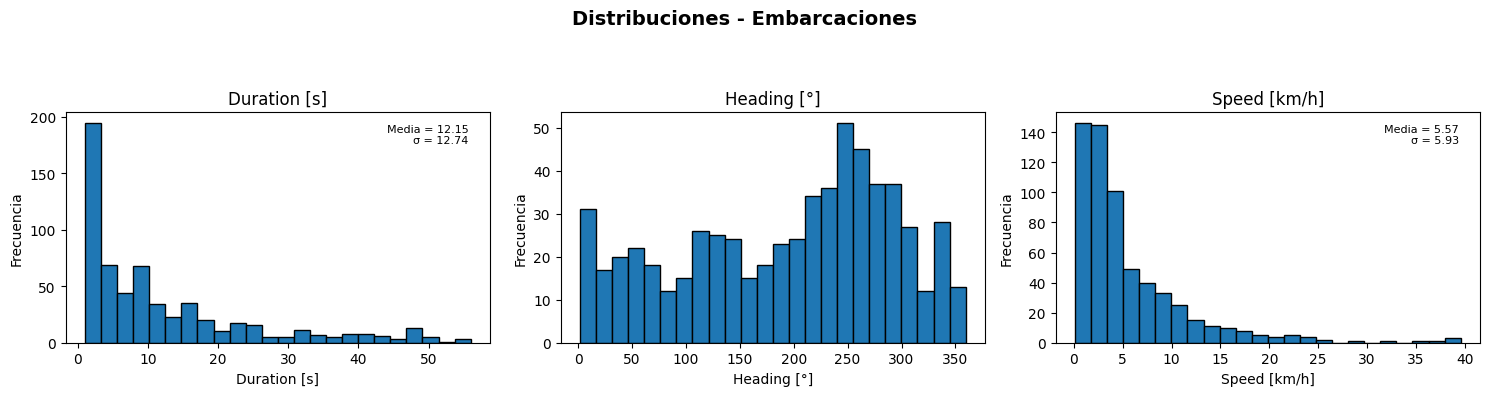

In [78]:
Ruta_DB = os.path.normpath(os.path.join("..","..","..","DB_Embarcaciones.csv"))

Database = {
    "No_Imagenes":{
        'Duration [s]':[],
        'Latitude':[],
        'Longitude':[],
        'Heading [°]':[],
        'Speed [km/h]':[],
        'System_Time':[]
    },
    "No_Embarcaciones":{
        'Duration [s]':[],
        'Latitude':[],
        'Longitude':[],
        'Heading [°]':[],
        'Speed [km/h]':[],
        'System_Time':[]
    },
    "Embarcaciones":{        
        'Duration [s]':[],
        'Latitude':[],
        'Longitude':[],
        'Heading [°]':[],
        'Speed [km/h]':[],
        'System_Time':[]}}

Registros_Repetidos_No_Embarcaciones = 0
Registros_Repetidos_Embarcaciones = 0

with open(Ruta_DB, mode="r", newline='', encoding='utf-8') as infile:
    reader = csv.DictReader(infile)
    header = reader.fieldnames

    # Conjunto para evitar duplicados
    registros_vistos = set()

    for row in reader:
        # clave única: combinación de TrackID y Sub_ID
        clave_unica = (row['Track_ID'], row['Sub_ID'])

        if clave_unica in registros_vistos:
            if(row['Main_Label'] == '0'):
                Registros_Repetidos_No_Embarcaciones+=1
            elif(row['Main_Label'] == '1'):
                Registros_Repetidos_Embarcaciones+=1

            continue  # ya procesado, saltar
        registros_vistos.add(clave_unica)

        # Clasificación según tus condiciones
        if row['Image_Name'] == 'N/A':
            Database["No_Imagenes"]['Duration [s]'].append(extract_number(row['Duration']))
            Database["No_Imagenes"]['Latitude'].append(extract_number(row['Latitude']))
            Database["No_Imagenes"]['Longitude'].append(extract_number(row['Longitude']))
            Database["No_Imagenes"]['Heading [°]'].append(extract_number(row['Heading']))
            Database["No_Imagenes"]['Speed [km/h]'].append(extract_number(row['Speed']))
            Database["No_Imagenes"]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))


        elif row['Main_Label'] == '0':
            Database["No_Embarcaciones"]['Duration [s]'].append(extract_number(row['Duration']))
            Database["No_Embarcaciones"]['Latitude'].append(extract_number(row['Latitude']))
            Database["No_Embarcaciones"]['Longitude'].append(extract_number(row['Longitude']))
            Database["No_Embarcaciones"]['Heading [°]'].append(extract_number(row['Heading']))
            Database["No_Embarcaciones"]['Speed [km/h]'].append(extract_number(row['Speed']))
            Database["No_Embarcaciones"]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))

        else:
            Database["Embarcaciones"]['Duration [s]'].append(extract_number(row['Duration']))
            Database["Embarcaciones"]['Latitude'].append(extract_number(row['Latitude']))
            Database["Embarcaciones"]['Longitude'].append(extract_number(row['Longitude']))
            Database["Embarcaciones"]['Heading [°]'].append(extract_number(row['Heading']))
            Database["Embarcaciones"]['Speed [km/h]'].append(extract_number(row['Speed']))
            Database["Embarcaciones"]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))


for categoria, datos in Database.items():
    if (categoria == 'No_Imagenes'):
        Correos_Sin_Imagenes = len(datos['Duration [s]'])
    elif (categoria == 'No_Embarcaciones'):
        Correos_Sin_Embarcaciones = len(datos['Duration [s]'])
    else:
        Correos_Con_Embarcaciones = len(datos['Duration [s]'])

Total_Correos=Correos_Sin_Imagenes+Correos_Sin_Embarcaciones+Correos_Con_Embarcaciones
Total_Imagenes=Correos_Sin_Embarcaciones+Registros_Repetidos_No_Embarcaciones+Correos_Con_Embarcaciones+Registros_Repetidos_Embarcaciones

print(f"La base de datos contiene un aproximado de {Total_Correos} correos diferentes")
print(f"La cantidad de correos sin imagenes son: {Correos_Sin_Imagenes}, corresponde a un {round(Correos_Sin_Imagenes*100/Total_Correos,3)}% de los correos\n")

print(f"La cantidad de correos con imagenes son: {Correos_Sin_Embarcaciones+Correos_Con_Embarcaciones}, corresponde a un {round((Correos_Sin_Embarcaciones+Correos_Con_Embarcaciones)*100/Total_Correos,3)}% de los correos")
print(f"Los correos que tienen imagenes pero no contienen embarcaciones son: {Correos_Sin_Embarcaciones}, corresponde a un {round(Correos_Sin_Embarcaciones*100/Total_Correos,3)}% de los correos")
print(f"Los correos que tienen imagenes y que contienen embarcaciones son: {Correos_Con_Embarcaciones}, corresponde a un {round(Correos_Con_Embarcaciones*100/Total_Correos,3)}% de los correos\n")

print(f"En total se disponen de {Correos_Sin_Embarcaciones+Registros_Repetidos_No_Embarcaciones} Imagenes sin embarcaciones")
print(f"En total se disponen de {Correos_Con_Embarcaciones+Registros_Repetidos_Embarcaciones} Imagenes con embarcaciones")
print(f"Se obtuvieron un total de {Total_Imagenes} Imagenes")

with PdfPages(os.path.normpath(os.path.join(Ruta_Salida,"histogramas_DB.pdf"))) as pdf:

    for categoria, variables in Database.items():
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f"Distribuciones - {categoria}", fontsize=14, fontweight="bold")

        columnas = ["Duration [s]", "Heading [°]", "Speed [km/h]"]

        for idx, nombre_var in enumerate(columnas):
            ax = axs[idx]
            valores = variables.get(nombre_var, [])

            if len(valores) > 0:
                ax.hist(valores, bins=int(math.sqrt(len(valores))), edgecolor="black")
                ax.set_title(nombre_var)
                ax.set_xlabel(nombre_var)
                ax.set_ylabel("Frecuencia")

                # Calcular media y desviación estándar solo en Duration y Speed
                if nombre_var in ["Duration [s]", "Speed [km/h]"] and len(valores) > 1:
                    media = stats.mean(valores)
                    sigma = stats.stdev(valores)

                    ax.text(
                        0.95, 0.95,
                        f"Media = {media:.2f}\nσ = {sigma:.2f}",
                        ha="right", va="top",
                        transform=ax.transAxes,
                        fontsize=8,
                        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
                    )
            else:
                ax.text(0.5, 0.5, "Sin datos", ha="center", va="center")
                ax.set_title(nombre_var)

        plt.tight_layout(rect=[0, 0, 1, 0.9])
        plt.show()

        pdf.savefig(fig)
        plt.close(fig)  



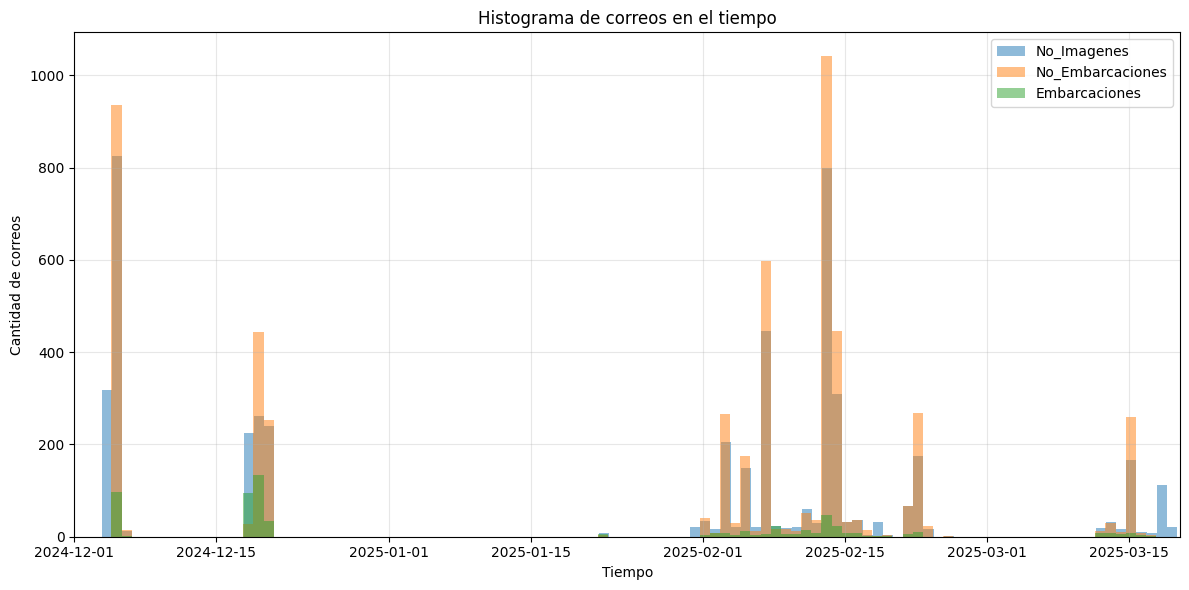

In [94]:
import pandas as pd


plt.figure(figsize=(12,6))

for categoria, datos in Database.items():
    if len(datos["System_Time"]) > 0:
        times = pd.to_datetime(datos["System_Time"])
        min_time = times.min()
        max_time = times.max()
        
        # Definir número de bins = número de días o semanas
        bins = pd.date_range(start=min_time, end=max_time, freq='D')  # un bin por día
        plt.hist(times, bins=bins, alpha=0.5, label=categoria)

fecha_min = pd.to_datetime("2024-12-01 00:00:00")
fecha_max = pd.to_datetime("2025-3-20 00:00:00")
plt.xlim(fecha_min, fecha_max)

plt.title("Histograma de correos en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de correos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()